In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [2]:
# ===== RUTAS =====
PROJECT_ROOT = Path.cwd().resolve().parents[3]

NOMBRE_SCALED = "CIC17__scaled__v1"
NOMBRE_PCA = "CIC17__pca__v1"

RUTA_SCALED = PROJECT_ROOT / "02_datasets" / "processed_analisis_estadistico" / NOMBRE_SCALED
RUTA_SALIDA = PROJECT_ROOT / "02_datasets" / "processed_analisis_estadistico" / NOMBRE_PCA

# ===== ARCHIVOS =====
TRAIN_FILE = f"{NOMBRE_SCALED}__train.csv"

PLOT_FILE = "pca_variance_plot.png"
REPORT_FILE = f"{NOMBRE_PCA}_report.json"

# ===== CONFIG =====
LABEL_COL = "LABEL"
VARIANCE_THRESHOLD = 0.95

In [3]:
print("Ruta entrada:", RUTA_SCALED)
print("Ruta salida:", RUTA_SALIDA)

Ruta entrada: /LUSTRE/home/inginf/u32902122/TFG/02_datasets/processed_analisis_estadistico/CIC17__scaled__v1
Ruta salida: /LUSTRE/home/inginf/u32902122/TFG/02_datasets/processed_analisis_estadistico/CIC17__pca__v1


In [4]:
train_path = RUTA_SCALED / TRAIN_FILE

if not train_path.exists():
    raise FileNotFoundError(train_path)

df = pd.read_csv(train_path)

print("Shape:", df.shape)

Shape: (2016638, 48)


In [5]:
X = df.drop(columns=[LABEL_COL])

print("Número de features:", X.shape[1])

Número de features: 47


In [6]:
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [7]:
k = np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1

print(f"k para {VARIANCE_THRESHOLD*100}% de varianza:", k)

k para 95.0% de varianza: 2


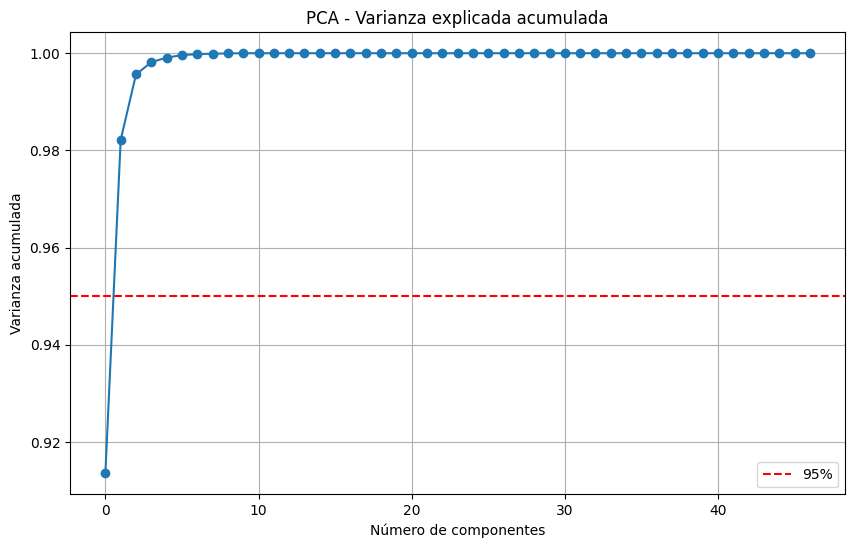

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label='95%')

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.grid(True)
plt.legend()

plt.show()

In [9]:
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance)
plt.axhline(y=VARIANCE_THRESHOLD, linestyle='--')

plt.savefig(RUTA_SALIDA / PLOT_FILE)
plt.close()

In [10]:
if k < 5:
    interpretacion = "Alta redundancia en las características"
elif k > 30:
    interpretacion = "Alta complejidad del espacio → justifica uso de LLM"
else:
    interpretacion = "Complejidad moderada del dataset"

print("Interpretación:", interpretacion)

Interpretación: Alta redundancia en las características


In [11]:
reporte = {
    "dataset": NOMBRE_SCALED,
    "num_features_original": int(X.shape[1]),
    "variance_threshold": VARIANCE_THRESHOLD,
    "k_components_95_variance": int(k),
    "explained_variance_first_10": explained_variance[:10].tolist(),
    "interpretation": interpretacion
}

with open(RUTA_SALIDA / REPORT_FILE, "w") as f:
    json.dump(reporte, f, indent=2)

print("Reporte guardado")

Reporte guardado


In [12]:
print("========== PCA RESULT ==========")
print("Features originales:", X.shape[1])
print("k (95% varianza):", k)
print("Interpretación:", interpretacion)
print("===============================")

========== PCA RESULT ==========
Features originales: 47
k (95% varianza): 2
Interpretación: Alta redundancia en las características
